# Sales Forecasting

JD.com Apple iPhone daily sales. Trying Linear Regression, ARIMA, SARIMA, SARIMAX and Prophet.


## 1) Imports


In [65]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet


## 2) Load the data


In [66]:
df = pd.read_csv("JD.com Apple iPhone Daily Sales.csv")
df.head()

,date,sales_quantity,promotion_flag,sku_id,product_name,category,brand,price
0,2022-01-01,2134,0,100251183595,Apple iPhone,手机通讯,Apple,8999元
1,2022-01-02,2658,1,100251183595,Apple iPhone,手机通讯,Apple,8999元
2,2022-01-03,2018,0,100251183595,Apple iPhone,手机通讯,Apple,8999元
3,2022-01-04,2183,0,100251183595,Apple iPhone,手机通讯,Apple,8999元
4,2022-01-05,1941,0,100251183595,Apple iPhone,手机通讯,Apple,8999元


In [67]:
print("shape:", df.shape)
print("-"*50)
print(df.dtypes)

shape: (1250, 8)
--------------------------------------------------
date                str
sales_quantity    int64
promotion_flag    int64
sku_id            int64
product_name        str
category            str
brand               str
price               str
dtype: object


In [68]:
print("missing values:")
print(df.isnull().sum())

missing values:
date              0
sales_quantity    0
promotion_flag    0
sku_id            0
product_name      0
category          0
brand             0
price             0
dtype: int64


## 3) Quick look at sales over time


In [69]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

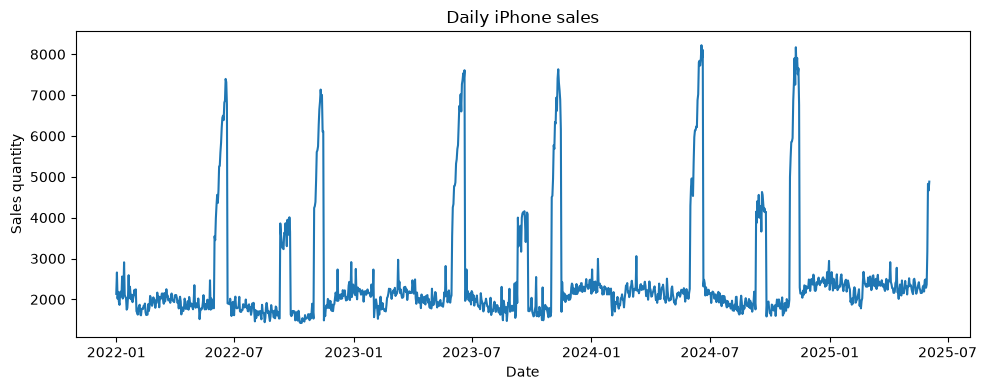

In [70]:

plt.figure(figsize=(10, 4))
plt.plot(df["date"], df["sales_quantity"])
plt.xlabel("Date")
plt.ylabel("Sales quantity")
plt.title("Daily iPhone sales")
plt.tight_layout()
plt.show()


In [71]:

print("date range:", df["date"].min().date(), "to", df["date"].max().date())
print("avg sales:", round(df["sales_quantity"].mean(), 1))
print("promo days avg:", round(df.loc[df["promotion_flag"] == 1, "sales_quantity"].mean(), 1))
print("normal days avg:", round(df.loc[df["promotion_flag"] == 0, "sales_quantity"].mean(), 1))


date range: 2022-01-01 to 2025-06-03
avg sales: 2459.0
promo days avg: 4958.0
normal days avg: 2019.4


## 4) Preprocessing — date features

No missing values here. Pull year / month / day / dayofweek for the regression model.


In [72]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["dayofweek"] = df["date"].dt.dayofweek  # Mon=0 ... Sun=6

df.head()


,date,sales_quantity,promotion_flag,sku_id,product_name,category,brand,price,year,month,day,dayofweek
0,2022-01-01,2134,0,100251183595,Apple iPhone,手机通讯,Apple,8999元,2022,1,1,5
1,2022-01-02,2658,1,100251183595,Apple iPhone,手机通讯,Apple,8999元,2022,1,2,6
2,2022-01-03,2018,0,100251183595,Apple iPhone,手机通讯,Apple,8999元,2022,1,3,0
3,2022-01-04,2183,0,100251183595,Apple iPhone,手机通讯,Apple,8999元,2022,1,4,1
4,2022-01-05,1941,0,100251183595,Apple iPhone,手机通讯,Apple,8999元,2022,1,5,2


## 5) Train / test split (by time)

Last 20% of days = test. Same split for all models.


In [73]:
split_at = int(len(df) * 0.8)
train = df.iloc[:split_at].copy()
test = df.iloc[split_at:].copy()

print("train size:", len(train))
print("test size:", len(test))
print("test starts at:", test["date"].iloc[0].date())


train size: 1000
test size: 250
test starts at: 2024-09-27


In [74]:
def eval_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  R2:   {r2:.4f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

In [75]:
evaluation_metrics = []

## 6a) Linear Regression

Uses calendar features + promotion flag.


In [76]:
features = ["year", "month", "day", "dayofweek", "promotion_flag"]

lr = LinearRegression()
lr.fit(train[features], train["sales_quantity"])
lr_pred = lr.predict(test[features])

evaluation_metrics.append(eval_model("Linear Regression", test["sales_quantity"].values, lr_pred))

print("coefficients:")
for name, coef in zip(features, lr.coef_):
    print(f"  {name}: {coef:.2f}")


Linear Regression
  RMSE: 627.79
  MAE:  318.52
  R2:   0.7146
coefficients:
  year: 136.20
  month: -4.79
  day: 0.33
  dayofweek: 25.31
  promotion_flag: 2892.36


## 6b) ACF / PACF then ARIMA

Looking at ACF/PACF on differenced train sales to pick a rough order. then fit ARIMA.


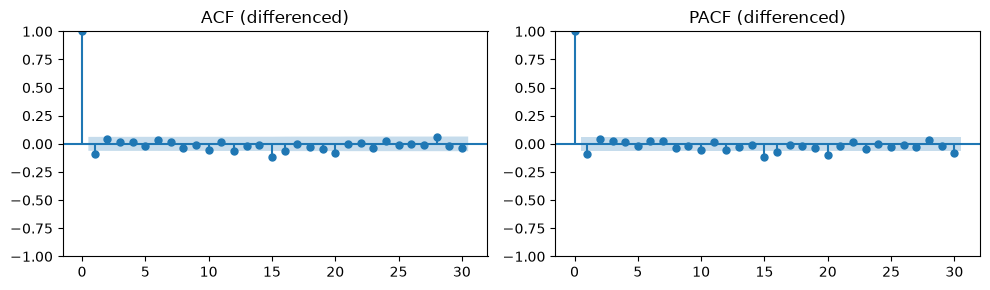

ARIMA(1, 1, 1) AIC=15231.2
ARIMA(2, 1, 1) AIC=15231.9
ARIMA(1, 1, 2) AIC=15231.8
ARIMA(2, 1, 2) AIC=15233.8
picked order: (1, 1, 1) AIC: 15231.2
ARIMA(1, 1, 1)
  RMSE: 1431.33
  MAE:  823.63
  R2:   -0.4838


In [77]:
# differenced series for ACF/PACF
train_diff = train["sales_quantity"].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(train_diff, lags=30, ax=axes[0])
plot_pacf(train_diff, lags=30, ax=axes[1], method="ywm")
axes[0].set_title("ACF (differenced)")
axes[1].set_title("PACF (differenced)")
plt.tight_layout()
plt.show()

# try a couple orders, keep the better one
candidates = [(1, 1, 1), (2, 1, 1), (1, 1, 2), (2, 1, 2)]
best_order = None
best_aic = np.inf
best_fit = None

for order in candidates:
    fit = ARIMA(train["sales_quantity"], order=order).fit()
    print(f"ARIMA{order} AIC={fit.aic:.1f}")
    if fit.aic < best_aic:
        best_aic = fit.aic
        best_order = order
        best_fit = fit

print("picked order:", best_order, "AIC:", round(best_aic, 1))
arima_fit = best_fit
arima_pred = arima_fit.forecast(steps=len(test)).values

evaluation_metrics.append(
    eval_model(f"ARIMA{best_order}", test["sales_quantity"].values, arima_pred)
)

## 6c) SARIMA

ARIMA + weekly seasonality (s=7) since data is daily.


In [78]:
# (p,d,q)x(P,D,Q,s)
sarima_fit = SARIMAX(
    train["sales_quantity"],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
).fit(disp=False)

sarima_pred = sarima_fit.forecast(steps=len(test)).values

evaluation_metrics.append(eval_model("SARIMA", test["sales_quantity"].values, sarima_pred))
print("SARIMA done")
print(sarima_fit.summary().tables[0])


SARIMA
  RMSE: 1392.40
  MAE:  759.71
  R2:   -0.4042
SARIMA done
                                     SARIMAX Results                                     
Dep. Variable:                    sales_quantity   No. Observations:                 1000
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -7607.325
Date:                           Sun, 02 Aug 2026   AIC                          15224.650
Time:                                   22:26:33   BIC                          15249.183
Sample:                                        0   HQIC                         15233.975
                                          - 1000                                         
Covariance Type:                             opg                                         


## 6d) SARIMAX

like SARIMA but can take extra inputs. using promotion_flag.


In [79]:
exog_train = train[["promotion_flag"]]
exog_test = test[["promotion_flag"]]

sarimax_fit = SARIMAX(
    train["sales_quantity"],
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
).fit(disp=False)

# need promo values for the future/test days too
sarimax_pred = sarimax_fit.forecast(steps=len(test), exog=exog_test).values
evaluation_metrics.append(eval_model("SARIMAX ", test["sales_quantity"].values, sarimax_pred))

print("SARIMAX done")
print(sarimax_fit.summary().tables[0])


SARIMAX 
  RMSE: 1148.74
  MAE:  742.71
  R2:   0.0443
SARIMAX done
                                     SARIMAX Results                                     
Dep. Variable:                    sales_quantity   No. Observations:                 1000
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -7331.157
Date:                           Sun, 02 Aug 2026   AIC                          14674.315
Time:                                   22:26:34   BIC                          14703.755
Sample:                                        0   HQIC                         14685.505
                                          - 1000                                         
Covariance Type:                             opg                                         


## 6e) Prophet

needs columns named ds (date) and y (target).


In [80]:
prophet_train = train[["date", "sales_quantity"]].rename(
    columns={"date": "ds", "sales_quantity": "y"}
)

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(test))
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast["yhat"].iloc[-len(test):].values

evaluation_metrics.append(eval_model("Prophet", test["sales_quantity"].values, prophet_pred))

print("Prophet done, test preds:", len(prophet_pred))


22:26:34 - cmdstanpy - INFO - Chain [1] start processing
22:26:34 - cmdstanpy - INFO - Chain [1] done processing


Prophet
  RMSE: 726.25
  MAE:  449.05
  R2:   0.6180
Prophet done, test preds: 250


## 7) Compare models


In [81]:
results = pd.DataFrame(evaluation_metrics)
print("\nsummary:")
print(results.round(4))



summary:
               model       RMSE       MAE      R2
0  Linear Regression   627.7874  318.5200  0.7146
1     ARIMA(1, 1, 1)  1431.3254  823.6285 -0.4838
2             SARIMA  1392.3989  759.7104 -0.4042
3           SARIMAX   1148.7419  742.7137  0.0443
4            Prophet   726.2544  449.0453  0.6180


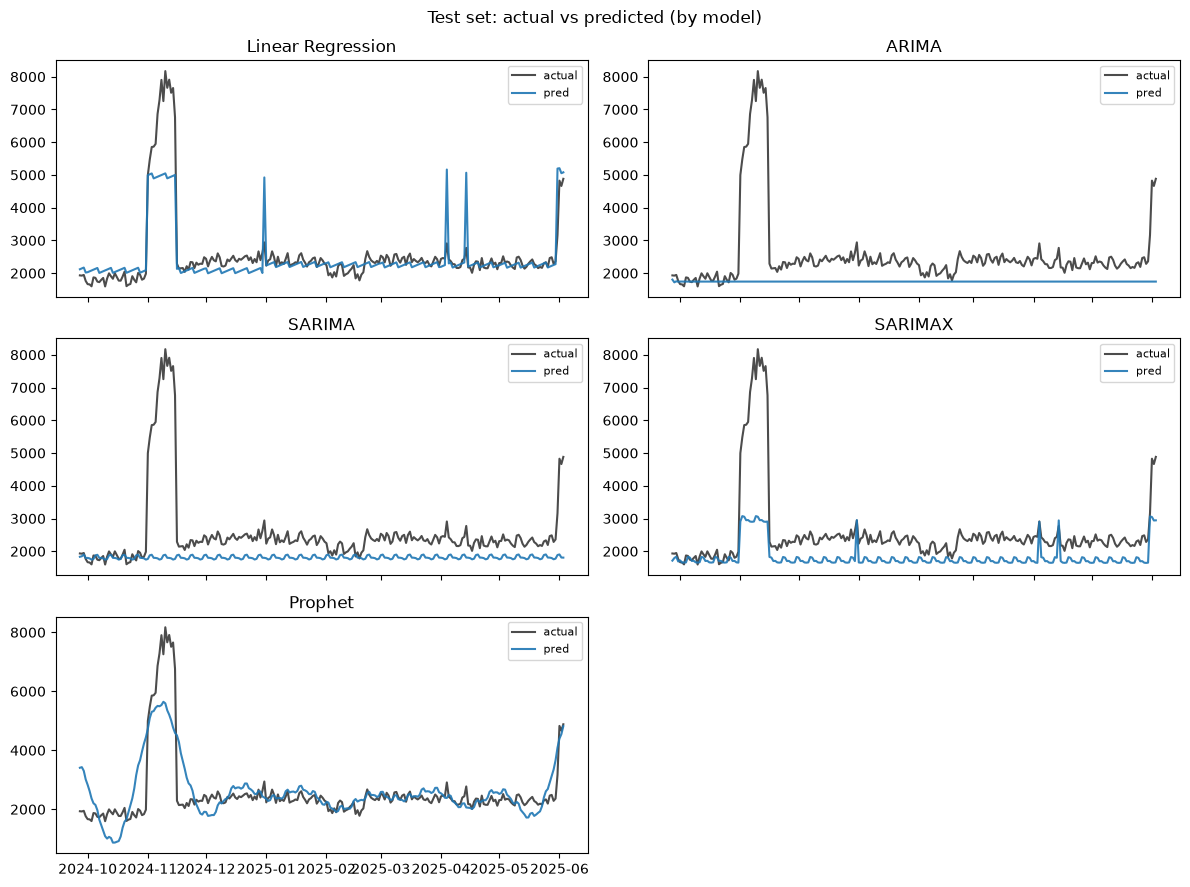

In [82]:
# separate subplot per model so its not one messy line soup
fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
axes = axes.ravel()

pairs = [
    ("Linear Regression", lr_pred),
    ("ARIMA", arima_pred),
    ("SARIMA", sarima_pred),
    ("SARIMAX", sarimax_pred),
    ("Prophet", prophet_pred),
]

for i, (name, pred) in enumerate(pairs):
    ax = axes[i]
    ax.plot(test["date"], test["sales_quantity"].values, label="actual", color="black", alpha=0.7)
    ax.plot(test["date"], pred, label="pred", alpha=0.9)
    ax.set_title(name)
    ax.legend(fontsize=8)

axes[-1].axis("off")
fig.suptitle("Test set: actual vs predicted (by model)")
plt.tight_layout()
plt.show()



## 8) Analysis

1250 daily rows (2022-01-01 to 2025-06-03), no missing values. promo days average about 4958 sales vs 2019 on normal days — roughly 2.5x higher. so promotions are the main swing factor in this series.

used a time based split (1000 train / 250 test, test from 2024-09-27). random split would leak future into train so that would be wrong for forecasting.

why linear regression won (rmse ~628, r2 ~0.71):
it gets promotion_flag as an input. that flag explains most of the big spikes. the coef on promo was huge (~2892), so when promo=1 the prediction jumps. calendar features help a bit with trend/seasonality but promo is doing the heavy lifting.

why ARIMA / SARIMA look bad (negative r2):
negative r2 means the model is worse than just predicting the test mean every day. these models only see past sales_quantity. they dont know which future days are promotions, so the forecast stays kinda flat and misses the spikes. i checked ACF/PACF and tried a few orders by AIC, but tuning p/q doesnt fix the missing promo signal. SARIMA with weekly seasonality (s=7) helps a little vs plain ARIMA but still negative r2 for the same reason.

SARIMAX is better than SARIMA because it takes promotion_flag as an exogenous input. still behind LR on this split though — LR is basically a simpler way to use the same promo info plus date parts.

Prophet sits in the middle (rmse ~726, r2 ~0.62). it models weekly/yearly seasonality from the date, but without promo as a regressor it still misses some peaks.

main takeaway: domain feature (promotion) beat fancy time series models here. if i continue, id add promo into Prophet as an extra regressor or keep LR/SARIMAX as the practical options.